In [1]:

# Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import write, read
from IPython.display import Audio
import IPython

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.signal import sawtooth, square
from IPython.display import Audio, HTML
    
%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

import soundfile as sf
from urllib.request import urlopen
import io

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")




Granular synthesis can be used for a wide range of synthesis and manipulation cases,
including time stretching.
One of the most interesting applications is the synthesis of endless sound textures from input samples.



In [2]:

# Function to Generate a Single Grain
def generate_grain(audio, grain_size, position):
    """Extracts a grain from the given audio signal."""
    start = int(position - grain_size // 2)
    end = int(position + grain_size // 2)
    start = max(0, start)  # Ensure indices are within bounds
    end = min(len(audio), end)

    grain = audio[start:end]
    
    win = sp.signal.windows.hann(len(grain))
        
    return grain*win


In [3]:

# Function for Granular Synthesis
def granular_synthesis(audio, grain_size, overlap, num_grains):
    """Performs granular synthesis by layering grains."""
    step = int(grain_size * (1 - overlap))
    grain_positions = np.arange(0, len(audio), step)
    output_length = len(audio)
    output = np.zeros(output_length)
    
    for pos in grain_positions[:num_grains]:
        grain = generate_grain(audio, grain_size, pos)
        
        # Determine where to place the grain in the output
        start = max(0, pos - grain_size // 2)
        end = min(output_length, start + len(grain))
        
        # Add grain to output
        output[start:end] += grain

    # Normalize the output
    output /= np.max(np.abs(output))
    return output


In [4]:

# Function for Randomized Granular Synthesis
def randomized_granular_synthesis(audio, grain_size, num_grains, density, output_length):
    
    """Creates an endless sound texture using randomized grain positions."""
    #output_length = len(audio)
    output = np.zeros(output_length)
    total_grains = int(num_grains * density)
    posvec = np.zeros(int(num_grains * density))
    
    for i in range(total_grains):
        position = np.random.randint(0, len(audio))  # Random grain position
        grain = generate_grain(audio, grain_size, position)
        
        # Random placement in the output
        start = np.random.randint(0, output_length - len(grain))
        end = start + len(grain)

        posvec[i] = start
        # Add grain to output
        output[start:end] += grain

    # Normalize the output
    output /= np.max(np.abs(output))
    
    return output,posvec


In [5]:


# Load an Audio File
url = 'https://ringbuffer.org/download/audio/chi_mono.wav'
audio_data, sample_rate  = sf.read(io.BytesIO(urlopen(url).read()))

if len(audio_data.shape) > 1:  # Convert stereo to mono if necessary
    audio_data = np.mean(audio_data, axis=1).astype(audio_data.dtype)


# Normalize Audio Data (if necessary)
if audio_data.dtype != np.float32:
    audio_data = audio_data / np.max(np.abs(audio_data))


# Granular Synthesis Parameters
grain_size = 5000   # Grain size in samples
overlap = 10       # Overlap between grains
num_grains = 3000    # Number of grains
density = 0.5       # Density of grains for randomized synthesis
output_length = 30*sample_rate

 
# Perform Randomized Granular Synthesis
randomized_granular_audio, posvec = randomized_granular_synthesis(audio_data, grain_size, num_grains, density, output_length)


----

# Original Signal

The original signal in this example is 

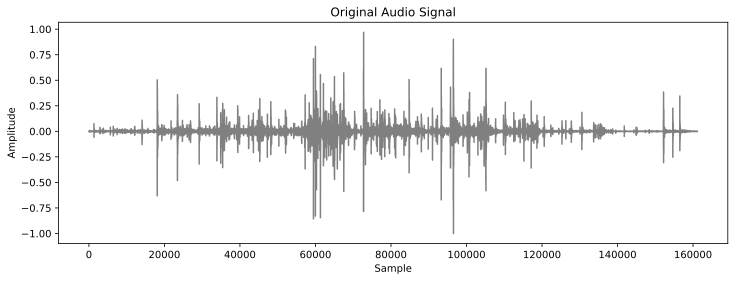

In [6]:
# Plot Original Signal and Granular Synthesized Signal
plt.figure(figsize=(12, 4))


plt.title("Original Audio Signal")
plt.plot(audio_data, color='gray')
plt.xlabel("Sample")
plt.ylabel("Amplitude");

In [7]:
# Save Output as WAV Files

# Play Original and Granular Synthesized Audio
print("Original Audio:")
Audio(audio_data, rate=sample_rate)

Original Audio:


----

# Random Grain Sequence

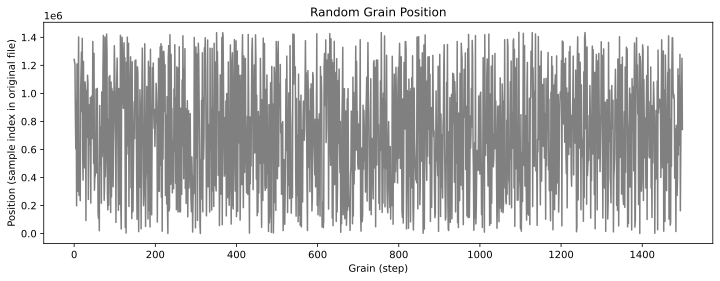

In [8]:
plt.figure(figsize=(12, 4))

plt.title("Random Grain Position")
plt.plot(posvec, color='gray')
plt.xlabel("Grain (step)")
plt.ylabel("Position (sample index in original file)");

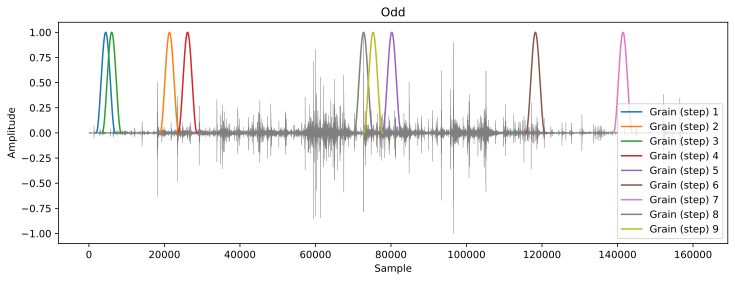

In [9]:
plt.figure(figsize=(12, 4))

plt.title("Odd")
plt.plot(audio_data, color='gray',linewidth=0.5)
plt.xlabel("Sample")
plt.ylabel("Amplitude")

steps = np.zeros(9)

for i in range(9):

    pos = np.random.rand()*150000 
    steps[i]=pos
    grain = generate_grain(audio_data, 5000, pos)
    
for i in range(9):

    plt.plot(np.linspace(steps[i],steps[i]+5000,5000) , sp.signal.windows.hann(5000),label='Grain (step) '+str(i+1))

plt.legend();

----

## Single Grain Plots



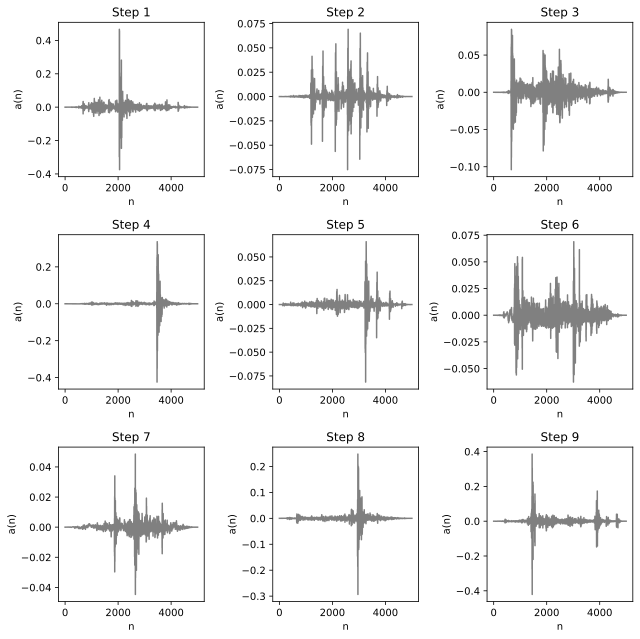

In [10]:
plt.figure(figsize=(9, 9))


for i in range(9):

    pos = np.random.rand()*150000 
    steps[i]=pos
    grain = generate_grain(audio_data, 5000, pos)

    plt.subplot(3,3,i+1)
    plt.plot(grain,'gray')
    plt.xlabel('n')
    plt.ylabel('a(n)')
    plt.title('Step '+str(i+1))
    
plt.tight_layout()
plt.show()

In [11]:
for i in range(9):

    pos = np.random.rand()*150000 
    steps[i]=pos
    grain = generate_grain(audio_data, 5000, pos)

    
    IPython.display.display(Audio(grain, rate=sample_rate))

----

# Stitching it Together

The grains are then stiched together with randomized distances or overlaps.

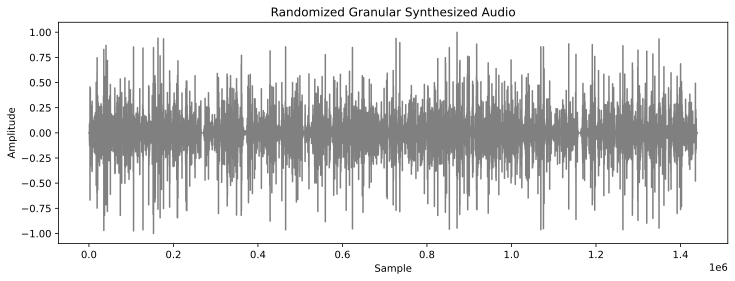

In [12]:

plt.figure(figsize=(12, 4))

plt.title("Randomized Granular Synthesized Audio")
plt.plot(randomized_granular_audio, color='gray')
plt.xlabel("Sample")
plt.ylabel("Amplitude");



In [13]:
print("Randomized Granular Synthesized Audio:")
Audio(randomized_granular_audio, rate=sample_rate)

Randomized Granular Synthesized Audio:
